# Cointegration

In [1]:
from statsmodels.tsa.stattools import coint
from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
filtered_residuals = pd.read_csv("../data/manipulated/pr_filtered_residuals.csv")

assets = filtered_residuals.columns

In [3]:
from sklearn.linear_model import LinearRegression

def find_cointegrated_pairs(residuals_df, candidates, pvalue_threshold=0.05):
    pairs = []
    tickers = list(candidates)

    for i in range(len(tickers)):
        for j in range(i+1, len(tickers)):
            a, b = tickers[i], tickers[j]
            _, pvalue, _ = coint(residuals_df[a], residuals_df[b])
            if pvalue < pvalue_threshold:
                # estimate hedge ratio
                model = LinearRegression().fit(
                    residuals_df[[b]], residuals_df[a]
                )
                beta = model.coef_[0]
                pairs.append((a, b, pvalue, beta))

    pairs_df = pd.DataFrame(pairs, columns=["asset_a", "asset_b", "pvalue", "beta"])
    return pairs_df.sort_values("pvalue")

In [4]:
cointegrated_pairs = find_cointegrated_pairs(filtered_residuals, assets)

In [5]:
cointegrated_pairs.head()

,asset_a,asset_b,pvalue,beta
280,HPQ,WY,0.0,0.761159
281,HPQ,KKR,0.0,0.798825
298,FTV,AVY,0.0,1.036690
283,HPQ,SBUX,0.0,0.933152
296,KKR,AVY,0.0,0.917810


In [6]:
cointegrated_pairs.to_csv("../data/manipulated/cointegrated_pairs.csv", index=False)

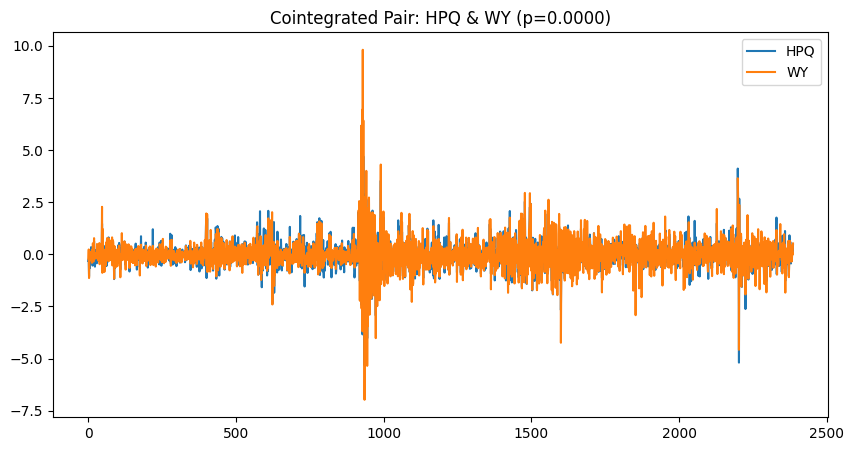

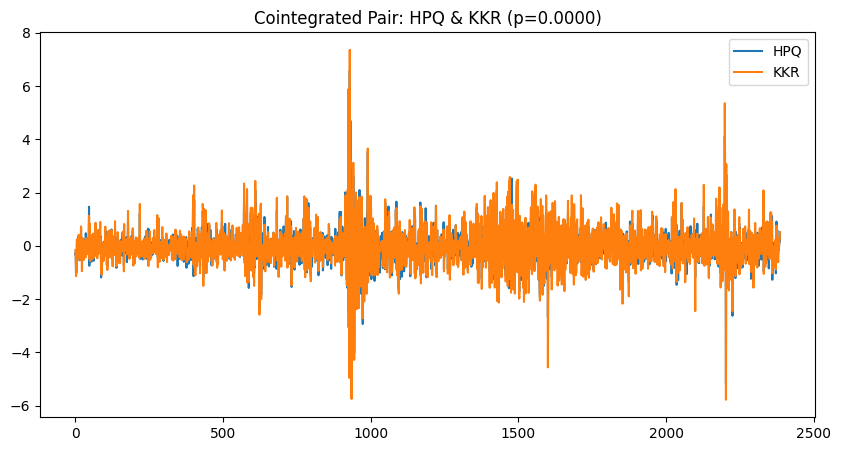

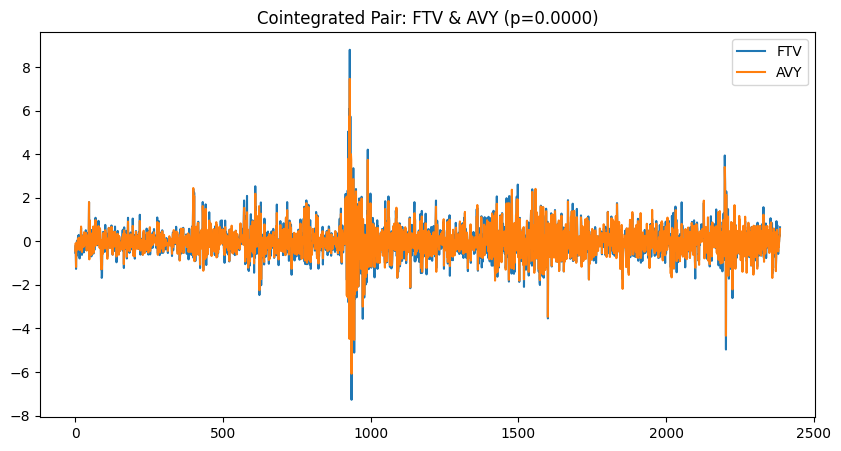

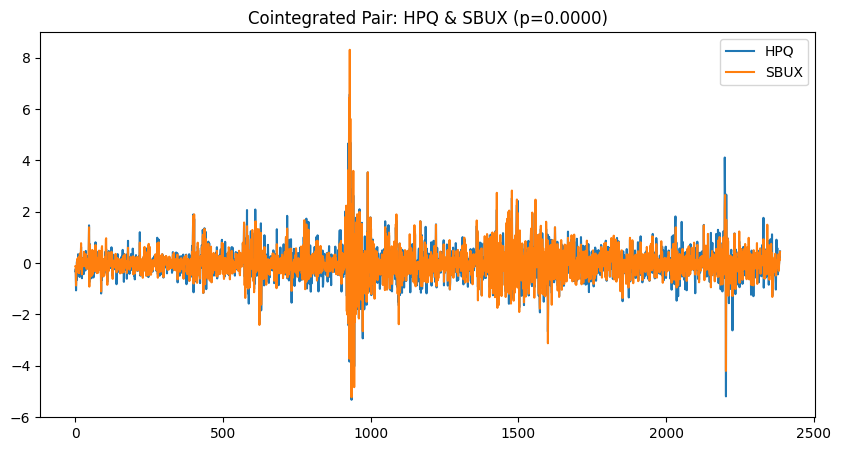

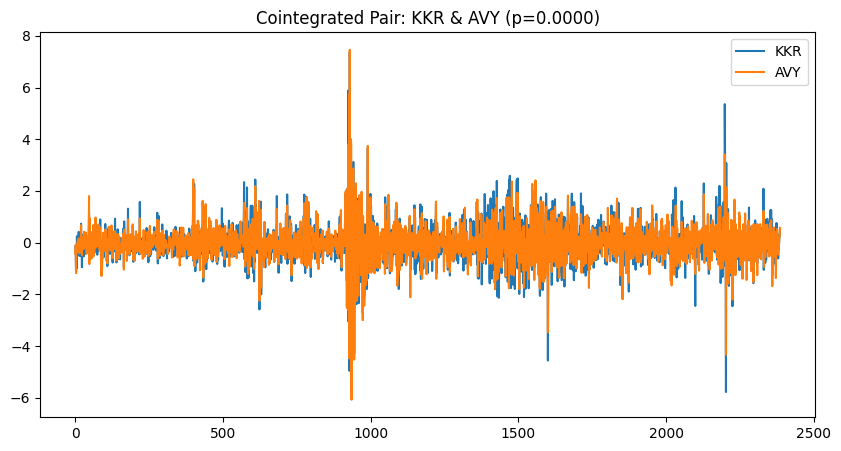

In [7]:
# make plot of top 5 most cointegrated pairs
top_pairs = cointegrated_pairs.head(5)
for _, row in top_pairs.iterrows():
    a, b = row["asset_a"], row["asset_b"]
    plt.figure(figsize=(10, 5))
    plt.plot(filtered_residuals[a], label=a)
    plt.plot(filtered_residuals[b], label=b)
    plt.title(f"Cointegrated Pair: {a} & {b} (p={row['pvalue']:.4f})")
    plt.legend()
    plt.show()